In [29]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [17]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 7.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.5 MB 5.0 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 5.9 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 6.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 6.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 6.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 5.9 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ----


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
df=pd.read_csv('Housing.csv')

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [12]:
df.shape

(545, 13)

In [13]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
X = X.select_dtypes(include=['number'])

In [20]:
X=df.drop('price',axis=1)
y=df['price']

In [23]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

     feature        VIF
0       area   6.737363
1   bedrooms  13.652525
2  bathrooms   9.155151
3    stories   6.683602
4    parking   1.901606


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

X_train_simple = X_train[['area']]   # choose 1 feature
X_test_simple = X_test[['area']]
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)
y_pred_simple = model_simple.predict(X_test_simple)

In [26]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return mae, rmse, r2

print("Simple:", evaluate(y_test, y_pred_simple))
print("Multiple:", evaluate(y_test, y_pred_multi))

Simple: (1474748.1337969352, np.float64(1917103.7021424233), 0.27287851871974644)
Multiple: (1127483.3523235188, np.float64(1514173.5520492233), 0.5464062355495871)


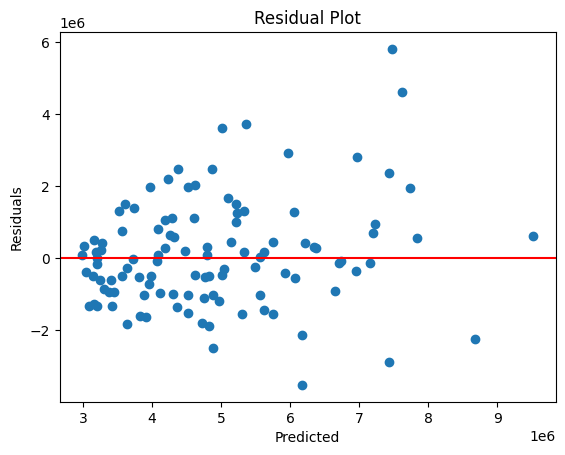

In [30]:
residuals = y_test - y_pred_multi
plt.scatter(y_pred_multi, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

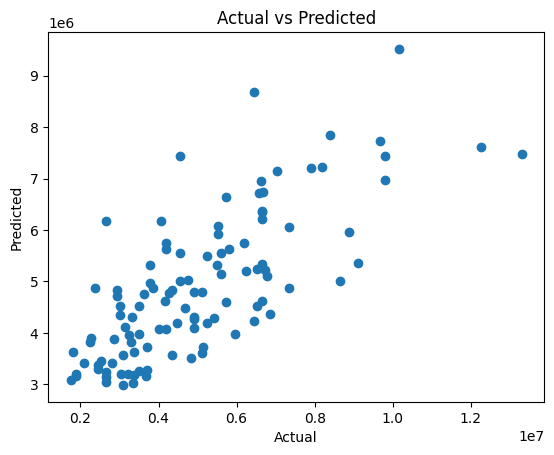

In [31]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()